In [ ]:
import pandas as pd
from matplotlib import pyplot as plt
%matplotlib inline

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train.csv


***1) EXPLORATORY DATA ANALYTICS:***

In [ ]:
df = pd.read_csv("train.csv")
df.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [ ]:
#to find the no of rows and coloumns
df.shape

(103904, 25)

In [ ]:
#to find the number of satisfied customers
satisfied = df[df.satisfaction=="satisfied"]
satisfied.shape

(45025, 25)

In [ ]:
#to find the number of neutral or dissatisfied customers
notsatisfied = df[df.satisfaction=="neutral or dissatisfied"]
notsatisfied.shape

(58879, 25)

In [40]:
df.satisfaction.value_counts()

,count
satisfaction,
0,58879
1,45025


In [ ]:
#average age of person travelling
avgage = df['Age'].mean()
print(avgage)

39.379706267323684


In [ ]:
df.groupby('satisfaction')['Age'].mean()

,Age
satisfaction,
neutral or dissatisfied,37.566688
satisfied,41.750583


the table shows ,<br>
avg age of satisfied customers = 41.75

avg age of neutral or dissatisfied customers = 37.56

In [ ]:
df.groupby('satisfaction')['Flight Distance'].mean()

,Flight Distance
satisfaction,
neutral or dissatisfied,928.919971
satisfied,1530.140255


table shows, <br>
avg flight distance of satisfied customers = 928.91

avg flight distance of neutral or dissatisfied customers = 1530.14

In [ ]:
df.groupby('satisfaction')['Departure Delay in Minutes'].mean()

,Departure Delay in Minutes
satisfaction,
neutral or dissatisfied,16.503728
satisfied,12.608084


table shows,<br>
customers are neutral or dissatisfied when the departure delay is approx 16.5 mins and satisfied with a departure delay uptill 12.6 mins

In [ ]:
df.groupby('satisfaction')['Arrival Delay in Minutes'].mean()

,Arrival Delay in Minutes
satisfaction,
neutral or dissatisfied,17.127536
satisfied,12.630799


table shows,<br>
customers are neutral or dissatisfied when the arrival delay is approx 17.12 mins and satisfied with a arrival delay uptill 12.63 mins

___________________________________________
***2) DATA VISUALISATIONS***

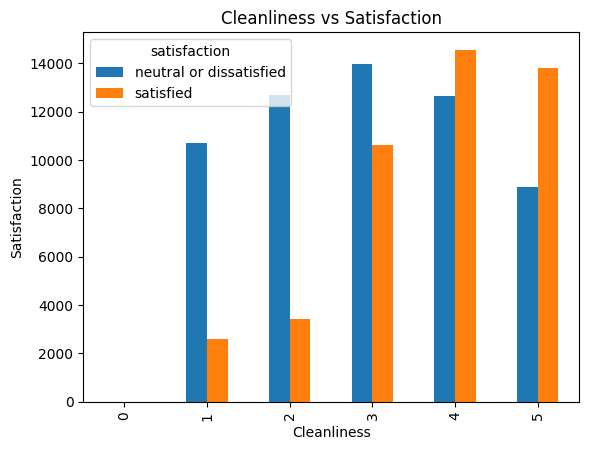

In [ ]:
# impact of cleanliness on satisfaction of customers
pd.crosstab(df.Cleanliness,df.satisfaction).plot(kind='bar')
plt.title('Cleanliness vs Satisfaction')
plt.xlabel('Cleanliness')
plt.ylabel('Satisfaction')
plt.show()

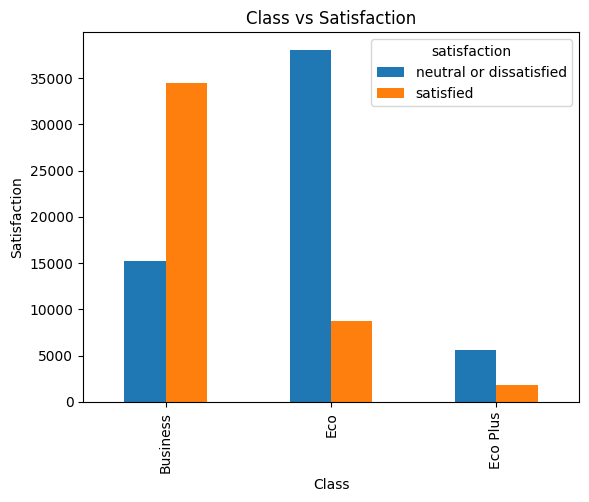

In [ ]:
# impact of class on satisfaction of customers
pd.crosstab(df.Class,df.satisfaction).plot(kind='bar')
plt.title('Class vs Satisfaction')
plt.xlabel('Class')
plt.ylabel('Satisfaction')
plt.show()

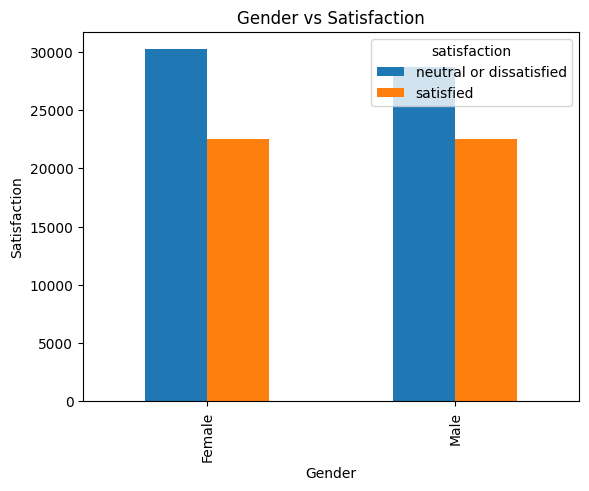

In [ ]:
# impact of gender on satisfaction of customers
pd.crosstab(df.Gender,df.satisfaction).plot(kind='bar')
plt.title('Gender vs Satisfaction')
plt.xlabel('Gender')
plt.ylabel('Satisfaction')
plt.show()

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


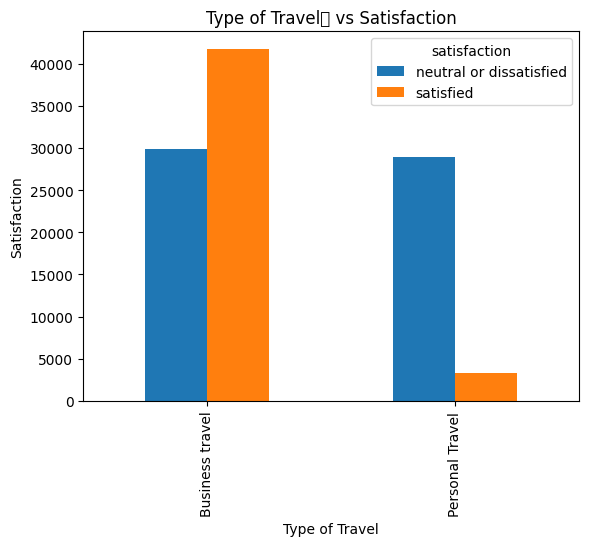

In [ ]:
# impact of "type of travel" on satisfaction of customers
pd.crosstab(df["Type of Travel"],df.satisfaction).plot(kind='bar')
plt.title('Type of Travel	 vs Satisfaction')
plt.xlabel('Type of Travel')
plt.ylabel('Satisfaction')
plt.show()

___________________________________________
3) ***5 KEY INSIGHTS***

1) Satisfaction is strongly impacted by class:


*   Buisness class passengers are far more satisfied
*   eco and eco plus mare more neutral or dissatisfied



2) Business Travelers Are Happier

*   Business travel passengers report more satisfaction than personal travel passengers.

3) Inflight Services leads to higher satisfaction

*   Features like Inflight Wifi, Online Boarding, and Inflight Entertainment are leads to satisfied passengers.

4) Delays Affect Satisfaction

*   Passengers with zero or low delay times (departure or arrival) are more likely to be satisfied.
*   Longer departure/arrival delays are linked with higher dissatisfaction.

5) loyalty and satisfaction

*   Loyal customers (frequent flyers) report higher satisfaction compared to disloyal customers.

___________________________________________
4) ***CLEAN THE DATA AND HANDLE MISSING VALUES***

In [ ]:
print("Missing values before cleaning:\n", df.isnull().sum())

Missing values before cleaning:
 Unnamed: 0                             0
id                                     0
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes

This shows that the " Arrival delay in minutes " has 310 missing values

In [ ]:
median_value = df['Arrival Delay in Minutes'].median()
median_value

0.0

In [ ]:
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(median_value)

In [42]:
print("Missing values after cleaning:\n", df.isnull().sum()/len(df))

Missing values after cleaning:
 Unnamed: 0                           0.0
id                                   0.0
Gender                               0.0
Customer Type                        0.0
Age                                  0.0
Type of Travel                       0.0
Class                                0.0
Flight Distance                      0.0
Inflight wifi service                0.0
Departure/Arrival time convenient    0.0
Ease of Online booking               0.0
Gate location                        0.0
Food and drink                       0.0
Online boarding                      0.0
Seat comfort                         0.0
Inflight entertainment               0.0
On-board service                     0.0
Leg room service                     0.0
Baggage handling                     0.0
Checkin service                      0.0
Inflight service                     0.0
Cleanliness                          0.0
Departure Delay in Minutes           0.0
Arrival Delay in Minutes 

from the table we can see that the data has been cleaned and the missing values have been handled appropriately

___________________________________________
5) ***TRAINING DIFFERENT CLASSIFICATION MODELS***

1st model ( logistic regression )

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [ ]:
X = df.drop('satisfaction', axis=1)
y = df['satisfaction']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [ ]:
model.predict(X_test)

array([0, 0, 0, ..., 0, 1, 1])

In [ ]:
model.score(X_test , y_test)

0.7850440306048795

2nd model ( decision tree classifier )

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
dt_model.predict(X_test)

array([0, 0, 0, ..., 0, 1, 1])

In [ ]:
dt_model.score(X_test , y_test)

0.9493287137288869

3rd model ( random forest classifier )

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
rf_model.predict(X_test)

array([0, 0, 0, ..., 0, 1, 1])

In [ ]:
rf_model.score(X_test , y_test)

0.9631875270679948

___________________________________________
6) ***EVALUATE AND COMPARE TO FIND THE MOST ACCURATE MODEL***

After evaluation ,<br>the score of the three models are as follows :


1.   Logistic Regression : 0.7850440306048795
2.   Decision tree classification : 0.9493287137288869
3.   Random forest classification : 0.9631875270679948



Thus , <br>
random forest classification has the highest score and therefore is the most accurate one

___________________________________________
7) ***GENERATE AND INTERPRET A CONFUSION MATRIX FOR RANDOM FOREST CLASSIFICATION***

In [ ]:
y_predicted = model.predict(X_test)

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_predicted)
cm

array([[9447, 2266],
       [2201, 6867]])

<Axes: >

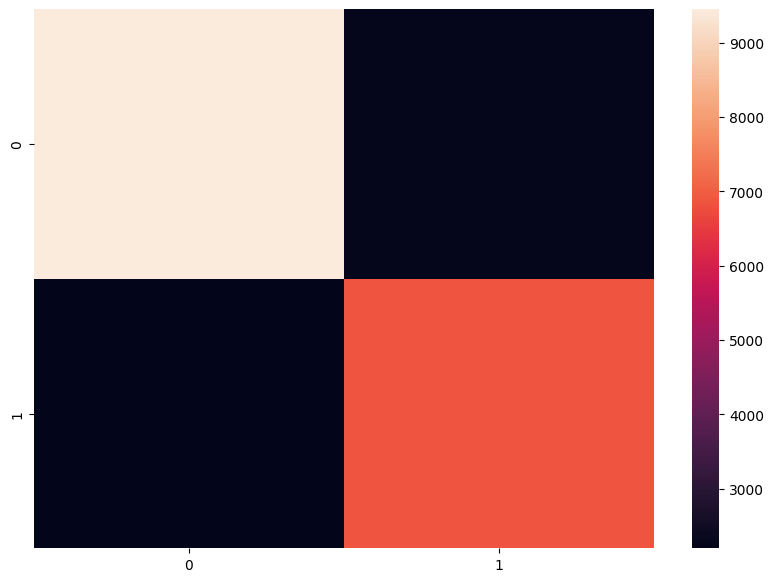

In [39]:
import seaborn as sn
plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True)

X______X______X_______X______X______X______X______X______X_______X______X______X______X______X_